# Гауссовский наивный байесовский классификатор

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from functools import partial
from pathlib import Path
import warnings
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import RobustScaler
from sklearn.pipeline import Pipeline
from research_utils.learning import grid_search, iteration_learning_score, get_top_n_info
from research_utils.plot import create_panel, plot_learning_curve, plot_complexity_and_accuracy, df_hist, df_scatter, series_hist, series_scatter
from research_utils.stats import agg_by_columns
from predictors.serialization import save_model
from predictors.feature_selection import ModelFeatureSelector
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import PowerTransformer
from scipy import stats
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [2]:
models_dir = Path("../models")
models_dir.mkdir(parents=True, exist_ok=True)

save = partial(save_model, models_dir)
train = pd.read_parquet("../data/processed/train.parquet")

## Подготовка данных
GaussianNB имеет следующие допущения:
- Предполагает нормальное распределение признаков
- Крайне чувствительна к выбросам, так как они сильно искажают оценки среднего и дисперсии.
- Мульти-коррелированные признаки вредят модели
- Сильно зависит от качества и информативности признаков

Таким образом, весь процесс предобработки будет похож на процесс предобработки логистической регресии

In [3]:
numeric_features = {
    'text__long_sentences_proportion', 
    'text__unpopular_words_proportion',
    'text__type_token_ratio',
    'text__mean_words_length',
    'text__lexicon_size',
    'entities__breadth_of_use_entities',
    'pos__mean_usage_NOUN', 
    'pos__mean_usage_PRON', 
    'pos__mean_usage_ADV',
    'pos__mean_usage_ADP', 
    'pos__mean_usage_SCONJ',
    'pos__mean_usage_CCONJ', 
    'pos__mean_usage_VERB',
    'pos__mean_usage_PROPN', 
    'pos__mean_usage_DET', 
    'pos__mean_usage_PART',
    "pos__ADJPOS_NOUN",
    "pos__PUNCT_SCONJ",
    "pos__ADP_ADJPOS",
    "pos__ADP_PRON",
    "pos__PUNCT_ADV",
    "pos__ADJPOS_PUNCT",
    "pos__PUNCT_CCONJ",
    'pos__index_of_formality_heylinger',
    'punct__breadth_of_use_puncts', 
    "punct__mean_usage_comma"
}
combo_features = { 
    "pos__pair_of_adv_per_sentence",
    "pos__mean_usage_AUX",
    "pos__mean_usage_NUM",
    "pos__PROPN_PUNCT",
    "pos__PUNCT_PRON",
    "punct__mean_usage_colon",
    "punct__mean_usage_question",
    "punct__mean_usage_openparen",
    "punct__mean_usage_closeparen",
    "punct__mean_usage_hyphen",
    "punct__mean_usage_exclamation",
    "entities__mean_usage_NUMBER",
    "entities__mean_usage_QUOTE",
    "entities__mean_usage_PUNCEM",
    "entities__mean_usage_ADDRESS",
}
typical_features = {
    'entities__mean_usage_MEAS_is_typical',
    'entities__mean_usage_ENUM_is_typical',
    'entities__mean_usage_FOREIGN_is_typical',
    'pos__breadth_of_use_pos_is_typical',
    'pos__index_of_formality_tuldava_is_typical',
    'entities__mean_usage_SMILE_is_typical',
    'entities__mean_usage_DATE_is_typical'
}
features = numeric_features | combo_features | typical_features
features_list = list(features) + [ f"{col}_used" for col in combo_features ]

In [4]:
var_smoothing = [ 1e-8, 1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 0.1, 1 ]
n_numeric_features = [10, 13, 16, 18, 21, 'all']

pipeline_params = {
    'model__var_smoothing': var_smoothing,
    'preprocessing__numeric__select_kbest__k': n_numeric_features,
}

numeric_fix_list = list(numeric_features.difference([
    "punct__breadth_of_use_puncts",
    "entities__breadth_of_use_entities",
    "pos__index_of_formality_heylinger",
    "text__type_token_ratio"
]))
combo_fix_list = list(combo_features)

def create_nb_pipeline(model_params=None):
    if not model_params:
        model_params = {}
    
    return Pipeline([
        ('get_features', ModelFeatureSelector(features_list)),
        ('power_transform', ColumnTransformer([
            ('numeric_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in numeric_fix_list if f in features_list]),
            ('combo_power', PowerTransformer(method='yeo-johnson', standardize=False), 
             [features_list.index(f) for f in combo_fix_list if f in features_list]),
        ], remainder='passthrough')),
        
        ('preprocessing', ColumnTransformer([
            ('numeric', Pipeline([
                ('select_kbest', SelectKBest(score_func=f_classif, k='all'))
            ]), [features_list.index(f) for f in numeric_features if f in features_list]),
        ], remainder='passthrough')),
        
        ('model', GaussianNB(**model_params))
    ])

## Независимые модели

### Классификатор пола

In [5]:
gender_pipeline = create_nb_pipeline()

gender_gs = grid_search(gender_pipeline, pipeline_params, train, train['gender'])

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [6]:
gender_gs.best_params_, gender_gs.best_score_

({'model__var_smoothing': 1e-08,
  'preprocessing__numeric__select_kbest__k': 10},
 np.float64(0.6375064935064936))

In [20]:
gender_top_5_info = get_top_n_info(gender_gs, n=5)
gender_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__var_smoothing,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.660064,0.020368,0.019506,0.002023,1.000000e-08,10,"{'model__var_smoothing': 1e-08, 'preprocessing...",0.636364,0.634805,0.625455,0.648312,0.642597,0.637506,0.007701,1
1,0.661997,0.037815,0.018858,0.002427,1.000000e-08,13,"{'model__var_smoothing': 1e-08, 'preprocessing...",0.637403,0.639481,0.616623,0.644675,0.647792,0.637195,0.010924,2
12,0.719626,0.049170,0.021858,0.004447,1.000000e-06,10,"{'model__var_smoothing': 1e-06, 'preprocessing...",0.633766,0.629091,0.625455,0.653506,0.643117,0.636987,0.010161,3
6,0.696629,0.049905,0.017347,0.000742,1.000000e-07,10,"{'model__var_smoothing': 1e-07, 'preprocessing...",0.635844,0.630649,0.625455,0.649870,0.642597,0.636883,0.008624,4
7,0.735174,0.065535,0.018959,0.001570,1.000000e-07,13,"{'model__var_smoothing': 1e-07, 'preprocessing...",0.636364,0.638961,0.617662,0.643636,0.647792,0.636883,0.010379,5


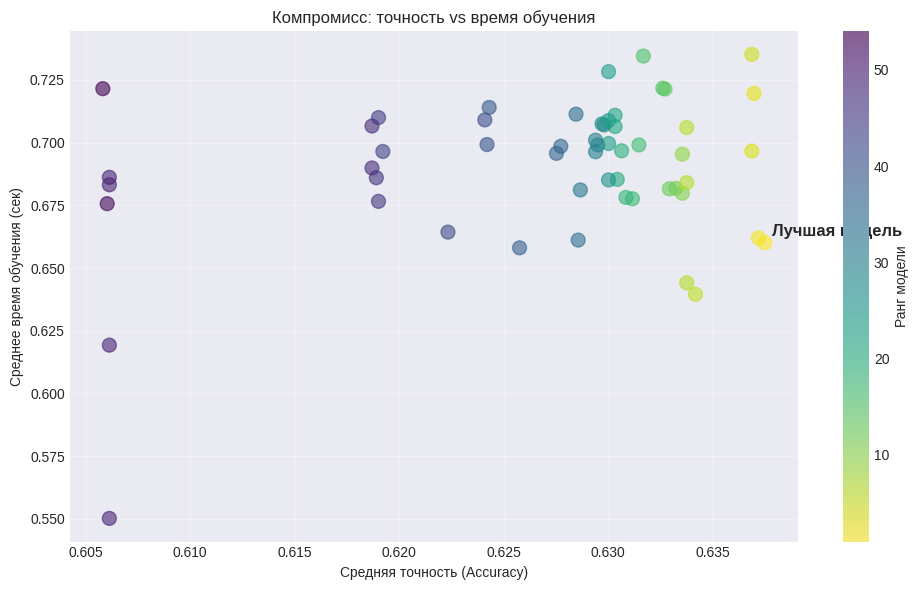

In [8]:
plot_complexity_and_accuracy(gender_gs)

In [13]:
gender_best_model_params = {
  'model__var_smoothing': 1e-8,
  'preprocessing__numeric__select_kbest__k': 10
}

gender_best_model = create_nb_pipeline()
gender_best_model.set_params(**gender_best_model_params)
gender_best_model_iter_learning_score = iteration_learning_score(gender_best_model, train, train['gender'])

In [14]:
alt_gender_model = create_nb_pipeline()
alt_gender_model.set_params(**
{
    'model__var_smoothing': 1e-8,
    'preprocessing__numeric__select_kbest__k': 'all'
}
)
alt_gender_model_iter_learning_score = iteration_learning_score(alt_gender_model, train, train['gender'])

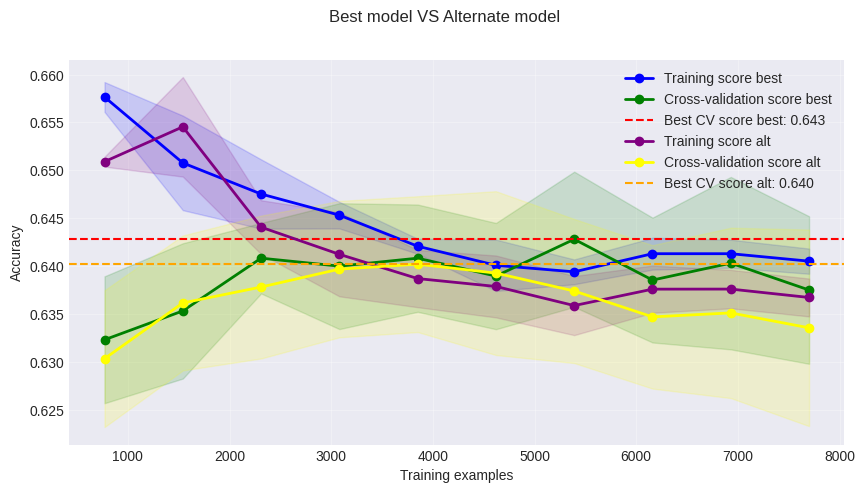

In [15]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*gender_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_gender_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Для сравнения использовались 2 конфигурации:
- Конфигурация с лучшим счетом по GS
- Конфигурация без отбора через KBest (все признаки - k=all)

Как видно по графику обучения, обе конфигурации видут себя схожим образом. Обе конфигурации достигают своего пика на 20%-40% точности, а затем падают на 0.5% при увеличении объема. Этим особенно страдает конфигурация без отбора признаков (alt), которая в результате обучения на 80% данных имеет показатель точности на валидационной выборке ниже, чем при обучении на 10%.

Лучший показатель - 64,3%

In [16]:
gender_best_model.fit(train, train['gender'])
save(
    gender_best_model, 
    "nb_gender_best", 
    gender_best_model_params, 
    { "val": gender_best_model_iter_learning_score[2].tolist(), "train": gender_best_model_iter_learning_score[1].tolist() }
)

### Классификатор возраста

In [17]:
age_pipeline = create_nb_pipeline()

age_gs = grid_search(age_pipeline, pipeline_params, train, train['age'])

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [18]:
age_gs.best_params_, age_gs.best_score_

({'model__var_smoothing': 1e-07,
  'preprocessing__numeric__select_kbest__k': 10},
 np.float64(0.5980259740259741))

In [19]:
age_top_5_info = get_top_n_info(age_gs, n=5)
age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__var_smoothing,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
6,0.735749,0.073465,0.017348,0.001507,1.000000e-07,10,"{'model__var_smoothing': 1e-07, 'preprocessing...",0.577143,0.599481,0.582338,0.619221,0.611948,0.598026,0.016293,1
0,0.919599,0.078210,0.035804,0.007767,1.000000e-08,10,"{'model__var_smoothing': 1e-08, 'preprocessing...",0.577143,0.599481,0.583377,0.618701,0.611429,0.598026,0.015874,2
12,0.722029,0.070939,0.018695,0.001096,1.000000e-06,10,"{'model__var_smoothing': 1e-06, 'preprocessing...",0.573506,0.596364,0.579740,0.618701,0.607273,0.595117,0.016787,3
1,0.922508,0.072540,0.036883,0.005853,1.000000e-08,13,"{'model__var_smoothing': 1e-08, 'preprocessing...",0.574545,0.598442,0.576623,0.611948,0.605195,0.593351,0.015136,4
7,0.679971,0.026680,0.019947,0.003044,1.000000e-07,13,"{'model__var_smoothing': 1e-07, 'preprocessing...",0.572468,0.596883,0.576623,0.612468,0.604675,0.592623,0.015617,5


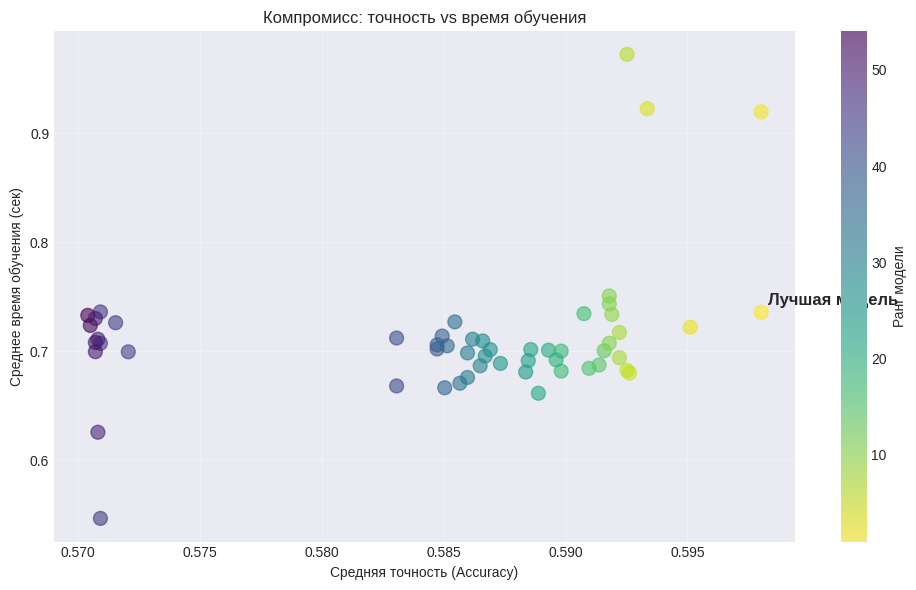

In [21]:
plot_complexity_and_accuracy(age_gs)

In [22]:
age_best_model_params = {
  'model__var_smoothing': 1e-7,
  'preprocessing__numeric__select_kbest__k': 10
}

age_best_model = create_nb_pipeline()
age_best_model.set_params(**age_best_model_params)
age_best_model_iter_learning_score = iteration_learning_score(age_best_model, train, train['age'])

In [23]:
alt_age_model = create_nb_pipeline()
alt_age_model.set_params(**
{
    'model__var_smoothing': 1e-7,
    'preprocessing__numeric__select_kbest__k': 'all'
}
)
alt_age_model_iter_learning_score = iteration_learning_score(alt_age_model, train, train['age'])

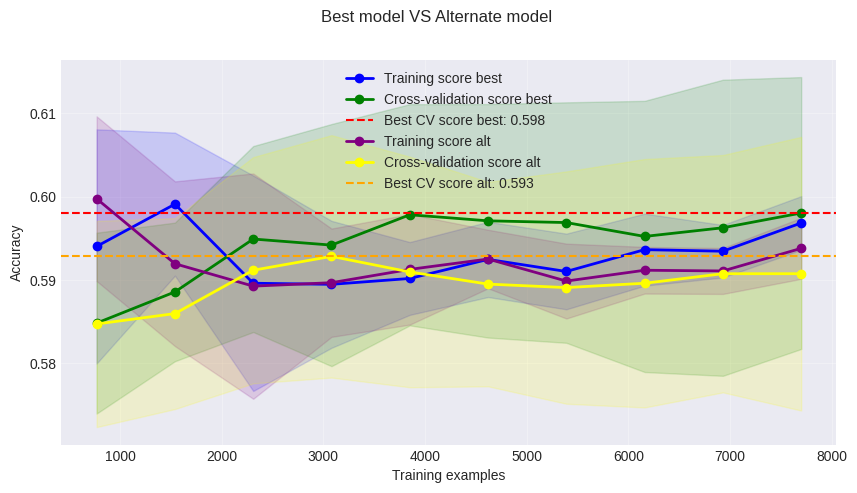

In [24]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternate model")
plt.show()

Лучшая точность - 59.8%. 

In [25]:
age_best_model.fit(train, train['age'])
save(
    age_best_model, 
    "nb_age_best", 
    age_best_model_params, 
    { "val": age_best_model_iter_learning_score[2].tolist(), "train": age_best_model_iter_learning_score[1].tolist() }
)

## Каскадный подход

Прогнозирование пола показывает более высокий показатель точности, по сравнению с прогнозирование возрастной группы. По этой причине сначала будет прогнозироваться пол, а затем в рамках пола - возраст

### Прогнозирование возраста мужчин

In [26]:
man_age_pipeline = create_nb_pipeline()

men_train = train[train['gender'] == 1]

men_age_gs = grid_search(man_age_pipeline, pipeline_params, men_train, men_train['age'])

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [27]:
men_age_gs.best_params_, men_age_gs.best_score_

({'model__var_smoothing': 0.01, 'preprocessing__numeric__select_kbest__k': 16},
 np.float64(0.6134534921736958))

In [28]:
men_age_top_5_info = get_top_n_info(men_age_gs, n=5)
men_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__var_smoothing,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
38,0.524116,0.011472,0.012756,0.000471,0.01,16,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.619732,0.615900,0.604406,0.616491,0.610738,0.613453,0.005364,1
39,0.540708,0.022722,0.013159,0.000725,0.01,18,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.616858,0.615900,0.603448,0.620326,0.609779,0.613262,0.005970,2
36,0.544540,0.030303,0.013601,0.000908,0.01,10,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.617816,0.613985,0.603448,0.616491,0.611697,0.612687,0.005075,3
37,0.541655,0.035037,0.012896,0.000901,0.01,13,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.619732,0.613985,0.602490,0.616491,0.610738,0.612687,0.005892,4
40,0.551035,0.039056,0.015619,0.001927,0.01,21,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.616858,0.611111,0.603448,0.620326,0.610738,0.612496,0.005783,5


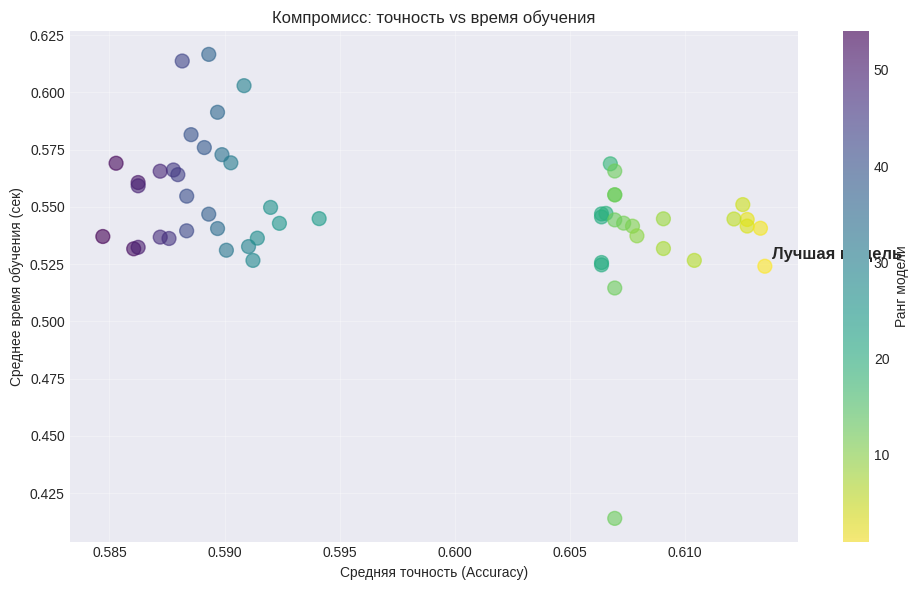

In [29]:
plot_complexity_and_accuracy(men_age_gs)

In [30]:
men_age_best_model_params = {
    'model__var_smoothing': 0.01,
    'preprocessing__numeric__select_kbest__k': 16
}
men_age_best_model = create_nb_pipeline()
men_age_best_model.set_params(**men_age_best_model_params)
men_age_best_model_iter_learning_score = iteration_learning_score(men_age_best_model, men_train, men_train['age'])

In [31]:
alt_men_age_model = create_nb_pipeline()
alt_men_age_model.set_params(**
{
    'model__var_smoothing': 0.01,                 
    'preprocessing__numeric__select_kbest__k': 'all'
}
)
alt_men_age_model_iter_learning_score = iteration_learning_score(alt_men_age_model, men_train, men_train['age'])

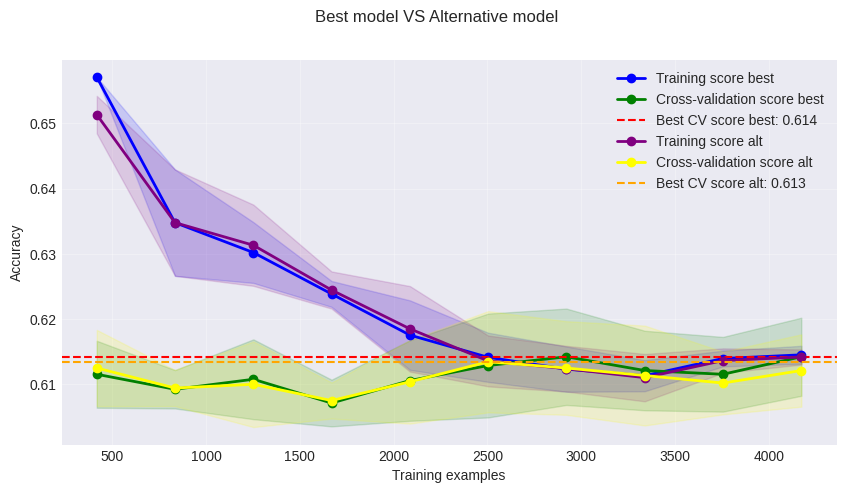

In [32]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*men_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_men_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Определение возраста в мужской подвыборке имеет точность на 1.5%, относительно общей модели

In [33]:
men_age_best_model.fit(men_train, men_train['age'])
save(
    men_age_best_model, 
    "nb_men_age_best", 
    men_age_best_model_params, 
    { "val": men_age_best_model_iter_learning_score[2].tolist(), "train": men_age_best_model_iter_learning_score[1].tolist() }
)

### Прогнозирование возраста женщин

In [34]:
woman_age_pipeline = create_nb_pipeline()

women_train = train[train['gender'] == 0]

women_age_gs = grid_search(woman_age_pipeline, pipeline_params, women_train, women_train['age'])

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [35]:
women_age_gs.best_params_, women_age_gs.best_score_

({'model__var_smoothing': 0.01, 'preprocessing__numeric__select_kbest__k': 10},
 np.float64(0.6392115226718762))

In [36]:
women_age_top_5_info = get_top_n_info(women_age_gs, n=5)
women_age_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__var_smoothing,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
36,0.514531,0.013176,0.014136,0.001043,0.01,10,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.633787,0.639456,0.642452,0.645857,0.634506,0.639212,0.004611,1
40,0.517978,0.065409,0.013923,0.001920,0.01,21,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.634921,0.641723,0.643587,0.637911,0.634506,0.638530,0.003616,2
41,0.530733,0.046400,0.014266,0.002427,0.01,all,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.634921,0.641723,0.643587,0.637911,0.634506,0.638530,0.003616,2
39,0.533496,0.007874,0.014625,0.002556,0.01,18,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.633787,0.641723,0.643587,0.637911,0.634506,0.638303,0.003862,4
38,0.522682,0.045148,0.016846,0.004963,0.01,16,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.633787,0.641723,0.643587,0.637911,0.633371,0.638076,0.004104,5


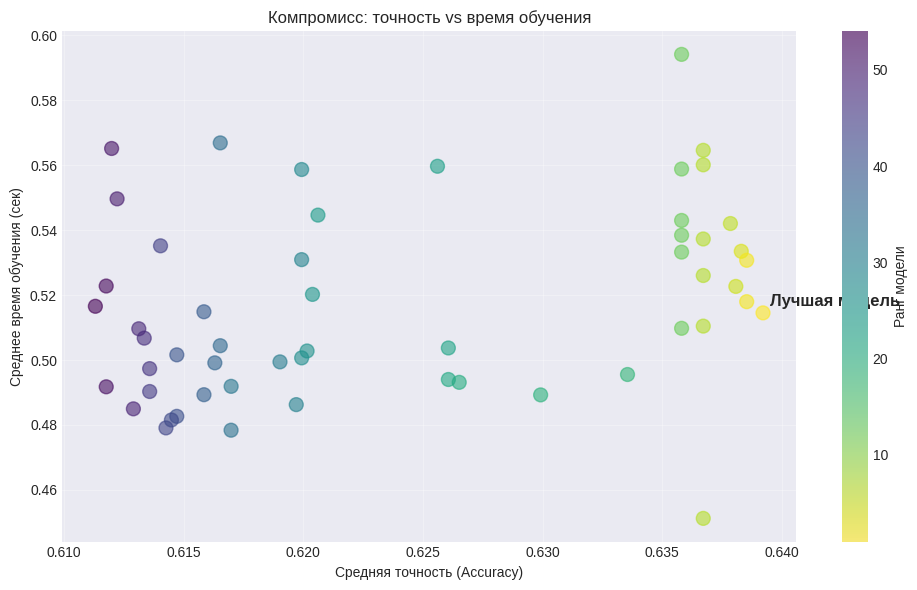

In [37]:
plot_complexity_and_accuracy(women_age_gs)

In [38]:
women_age_best_model_params = { 
    'model__var_smoothing': 0.01,
    'preprocessing__numeric__select_kbest__k': 10
}
women_age_best_model = create_nb_pipeline()
women_age_best_model.set_params(**women_age_best_model_params)
women_age_best_model_iter_learning_score = iteration_learning_score(women_age_best_model, women_train, women_train['age'])

In [39]:
alt_women_age_model = create_nb_pipeline()
alt_women_age_model.set_params(**
{
    'model__var_smoothing': 0.01,
    'preprocessing__numeric__select_kbest__k': 'all'
}
)
alt_women_age_model_iter_learning_score = iteration_learning_score(alt_women_age_model, women_train, women_train['age'])

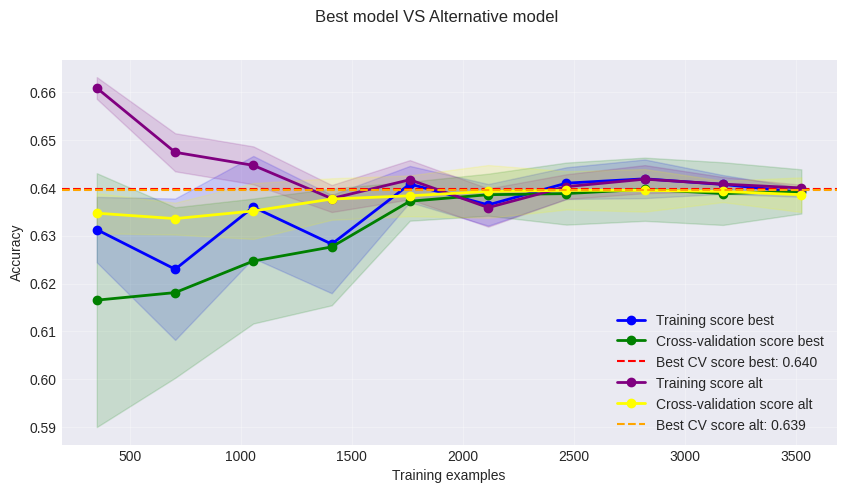

In [40]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*women_age_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*alt_women_age_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Использование каскадного подхода позволило слегка улучшить качество прогнозирования с 59.8% до 61,5-64%. Каждая модель стала лучше разбираться в рамках своего пола

In [41]:
women_age_best_model.fit(women_train, women_train['age'])
save(
    women_age_best_model, 
    "nb_women_age_best", 
    women_age_best_model_params, 
    { "val": women_age_best_model_iter_learning_score[2].tolist(), "train": women_age_best_model_iter_learning_score[1].tolist() }
)

## Плоский подход

In [42]:
flat_y_train = train['gender'] * 2 + train['age']

In [43]:
flat_pipeline = create_nb_pipeline()

flat_gs = grid_search(flat_pipeline, pipeline_params, train, flat_y_train)

Fitting 5 folds for each of 54 candidates, totalling 270 fits


In [44]:
flat_gs.best_params_, flat_gs.best_score_

({'model__var_smoothing': 0.001,
  'preprocessing__numeric__select_kbest__k': 10},
 np.float64(0.41267532467532464))

In [45]:
flat_top_5_info = get_top_n_info(flat_gs, n=5)
flat_top_5_info

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__var_smoothing,param_preprocessing__numeric__select_kbest__k,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
30,0.691153,0.044597,0.018236,0.000796,0.001,10,"{'model__var_smoothing': 0.001, 'preprocessing...",0.408312,0.387532,0.411429,0.441558,0.414545,0.412675,0.017266,1
31,0.713607,0.034764,0.019185,0.002020,0.001,13,"{'model__var_smoothing': 0.001, 'preprocessing...",0.406753,0.386494,0.403117,0.442597,0.416623,0.411117,0.018497,2
38,0.749696,0.041288,0.017775,0.001289,0.010,16,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.410390,0.401039,0.404675,0.424416,0.413506,0.410805,0.008071,3
32,0.704653,0.041083,0.017866,0.000808,0.001,16,"{'model__var_smoothing': 0.001, 'preprocessing...",0.405195,0.385974,0.403117,0.441558,0.417662,0.410701,0.018439,4
37,0.734265,0.051024,0.017474,0.000786,0.010,13,"{'model__var_smoothing': 0.01, 'preprocessing_...",0.408312,0.401039,0.404675,0.421818,0.414026,0.409974,0.007313,5


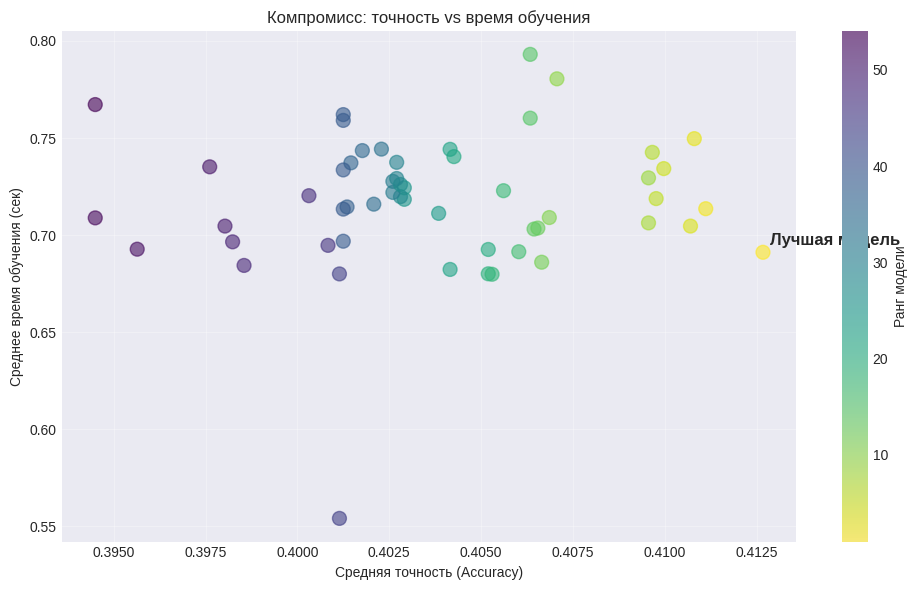

In [46]:
plot_complexity_and_accuracy(flat_gs)

In [47]:
flat_best_model_params = {
    'model__var_smoothing': 0.001,
    'preprocessing__numeric__select_kbest__k': 10
}
flat_best_model = create_nb_pipeline()
flat_best_model.set_params(**flat_best_model_params)
flat_best_model_iter_learning_score = iteration_learning_score(flat_best_model, train, flat_y_train)

In [48]:
flat_alt_model = create_nb_pipeline()
flat_alt_model.set_params(**{
    'model__var_smoothing': 0.001,
    'preprocessing__numeric__select_kbest__k': 'all'
})
flat_alt_model_iter_learning_score = iteration_learning_score(flat_alt_model, train, flat_y_train)

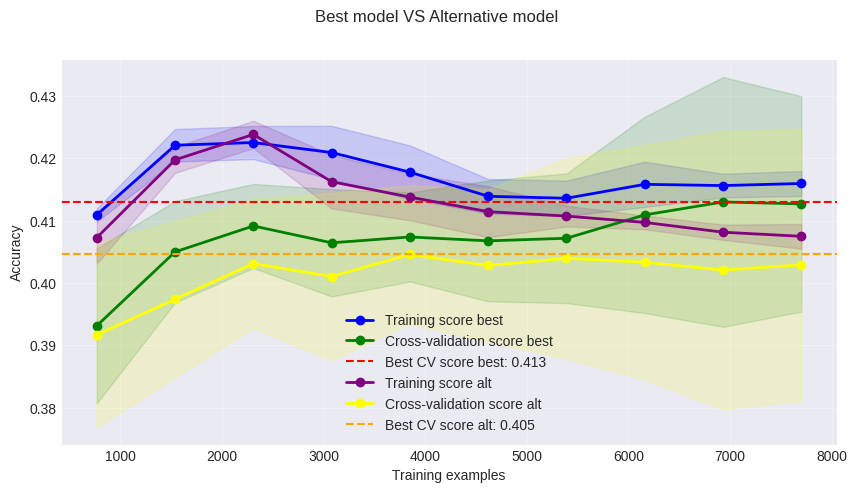

In [49]:
fig, axes = create_panel(1, cols=1, row_width=10)

plot_learning_curve(*flat_best_model_iter_learning_score, ax=axes.flat[0], name='best')
plot_learning_curve(*flat_alt_model_iter_learning_score, ax=axes.flat[0], name='alt', train_color="purple", val_color='yellow', score_color='orange')
plt.suptitle("Best model VS Alternative model")
plt.show()

Точность каскадного подхода приблизительно составит `0.643 * 0.598 = 0.385`. Плоский подход превосходит эту приблизительную точность на 3% процента.

In [50]:
flat_best_model.fit(train, flat_y_train)
save(
    flat_best_model, 
    "nb_flat_best", 
    flat_best_model_params, 
    { "val": flat_best_model_iter_learning_score[2].tolist(), "train": flat_best_model_iter_learning_score[1].tolist() }
)